<a href="https://colab.research.google.com/github/AnjaliAgrawal06/aiml-bootcamp-2026/blob/main/GLA_Sprint1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Calculate the avg marks and prin t class fialed or passed is the avg is 50 or above

In [2]:
marks = [45, 60, 72, 38, 90]

total = 0

for i in range(len(marks) - 1):
    total += marks[i]

average = total / len(marks)

if average > 50:
    print("Class passed")
else:
    print("Class failed")

print("Average:", average)

Class failed
Average: 43.0


In [3]:
import pandas as pd

In [4]:
data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}

df = pd.DataFrame(data)

df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True
5,106,88,19,80,True


In [5]:
df.shape

(6, 5)

In [6]:
df.head()

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          6 non-null      int64
 1   attendance_percent  6 non-null      int64
 2   assignment_score    6 non-null      int64
 3   quiz_score          6 non-null      int64
 4   lab_completed       6 non-null      bool 
dtypes: bool(1), int64(4)
memory usage: 330.0 bytes


In [8]:
df.describe()

,student_id,attendance_percent,assignment_score,quiz_score
count,6.000000,6.000000,6.000000,6.000000
mean,103.500000,74.500000,14.333333,58.333333
std,1.870829,17.073371,4.033196,18.007406
min,101.000000,45.000000,8.000000,30.000000
25%,102.250000,68.750000,12.500000,49.750000
50%,103.500000,77.500000,14.500000,60.000000
75%,104.750000,86.250000,17.250000,70.250000
max,106.000000,92.000000,19.000000,80.000000


In [9]:
df['total_score'] = df['assignment_score'] + df['quiz_score']
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score
0,101,92,18,72,True,90
1,102,67,12,48,False,60
2,103,81,15,65,True,80
3,104,45,8,30,False,38
4,105,74,14,55,True,69
5,106,88,19,80,True,99


In [10]:
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [11]:
eligible_students = df[df["eligible"] == True]
eligible_students

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


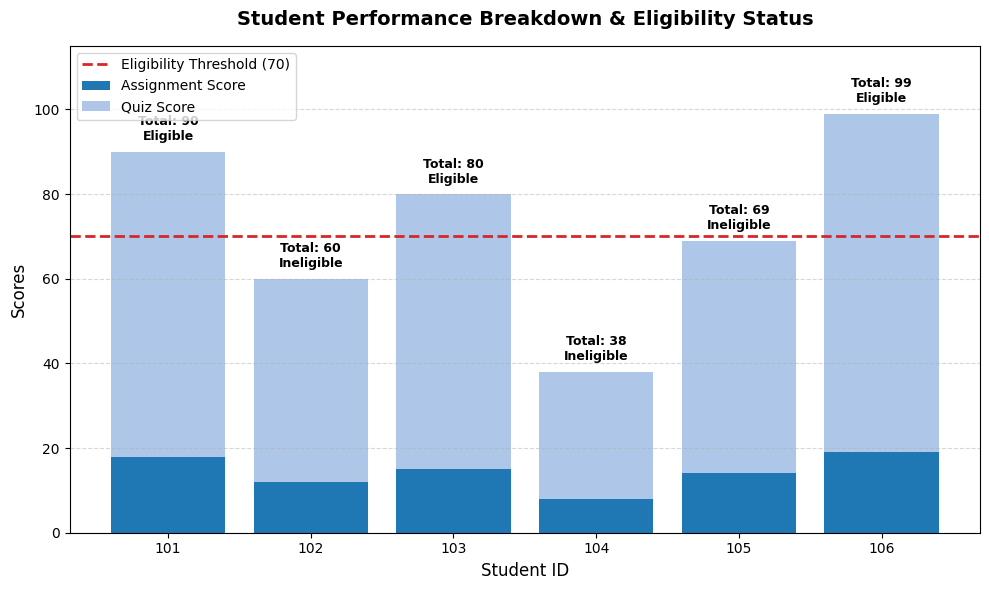

In [12]:
import matplotlib.pyplot as plt

student_ids = df['student_id'].astype(str)


plt.figure(figsize=(10, 6))

plt.bar(student_ids, df['assignment_score'], color='#1f77b4', label='Assignment Score')


plt.bar(student_ids, df['quiz_score'], bottom=df['assignment_score'], color='#aec7e8', label='Quiz Score')


plt.axhline(y=70, color='#d62728', linestyle='--', linewidth=2, label='Eligibility Threshold (70)')


for idx, row in df.iterrows():
    status = "Eligible" if row['eligible'] else "Ineligible"
    plt.text(
        x=idx,
        y=row['total_score'] + 2,
        s=f"Total: {row['total_score']}\n{status}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='semibold'
    )

plt.title('Student Performance Breakdown & Eligibility Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Student ID', fontsize=12)
plt.ylabel('Scores', fontsize=12)
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

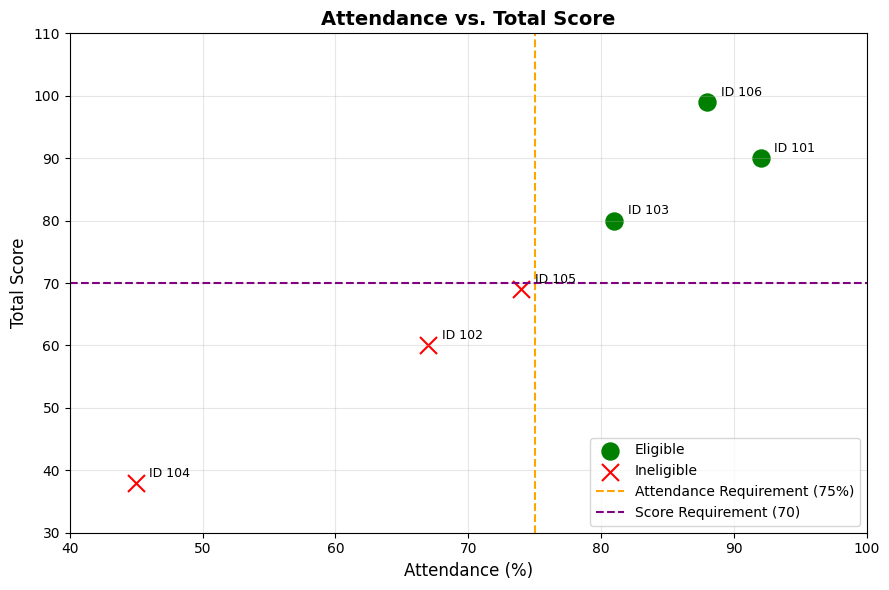

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))


eligible = df[df['eligible'] == True]
ineligible = df[df['eligible'] == False]

plt.scatter(eligible['attendance_percent'], eligible['total_score'], color='green', marker='o', s=150, label='Eligible')
plt.scatter(ineligible['attendance_percent'], ineligible['total_score'], color='red', marker='x', s=150, label='Ineligible')


plt.axvline(x=75, color='orange', linestyle='--', label='Attendance Requirement (75%)')
plt.axhline(y=70, color='purple', linestyle='--', label='Score Requirement (70)')


for idx, row in df.iterrows():
    plt.text(row['attendance_percent'] + 1, row['total_score'] + 1, f"ID {row['student_id']}", fontsize=9)

plt.title('Attendance vs. Total Score', fontsize=14, fontweight='bold')
plt.xlabel('Attendance (%)', fontsize=12)
plt.ylabel('Total Score', fontsize=12)
plt.xlim(40, 100)
plt.ylim(30, 110)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

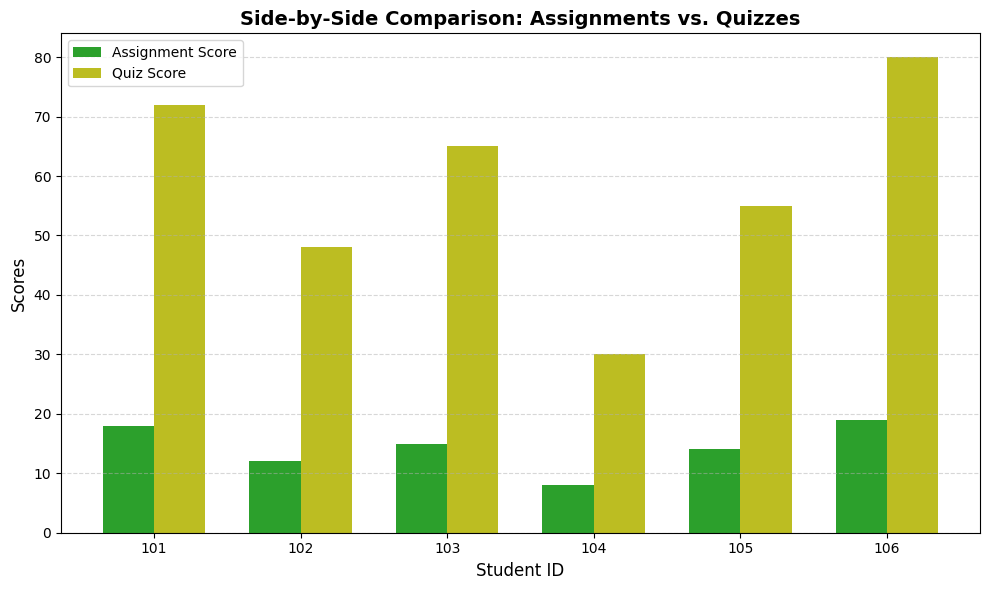

In [14]:
import numpy as np
import matplotlib.pyplot as plt

student_ids = df['student_id'].astype(str)
x = np.arange(len(student_ids))
width = 0.35

plt.figure(figsize=(10, 6))


plt.bar(x - width/2, df['assignment_score'], width, label='Assignment Score', color='#2ca02c')
plt.bar(x + width/2, df['quiz_score'], width, label='Quiz Score', color='#bcbd22')

plt.title('Side-by-Side Comparison: Assignments vs. Quizzes', fontsize=14, fontweight='bold')
plt.xlabel('Student ID', fontsize=12)
plt.ylabel('Scores', fontsize=12)
plt.xticks(x, student_ids)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

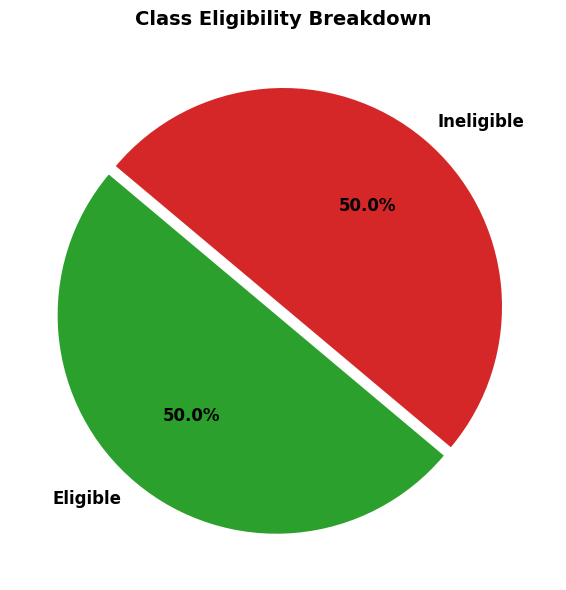

In [15]:
import matplotlib.pyplot as plt


eligibility_counts = df['eligible'].value_counts()
labels = ['Eligible' if idx else 'Ineligible' for idx in eligibility_counts.index]
colors = ['#2ca02c', '#d62728']

plt.figure(figsize=(6, 6))
plt.pie(
    eligibility_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0.05, 0) if len(eligibility_counts) > 1 else None,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title('Class Eligibility Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()